A centroid (bottom=0.0, top=1.00, x_cut=2): x=2.2222, y=0.4444
B centroid (bottom=0.0, top=0.10, x_cut=3.1): x=4.0248, y=0.0496
A+B centroid (A.x=2, B.x=3.1): x=2.4296, y=0.3990


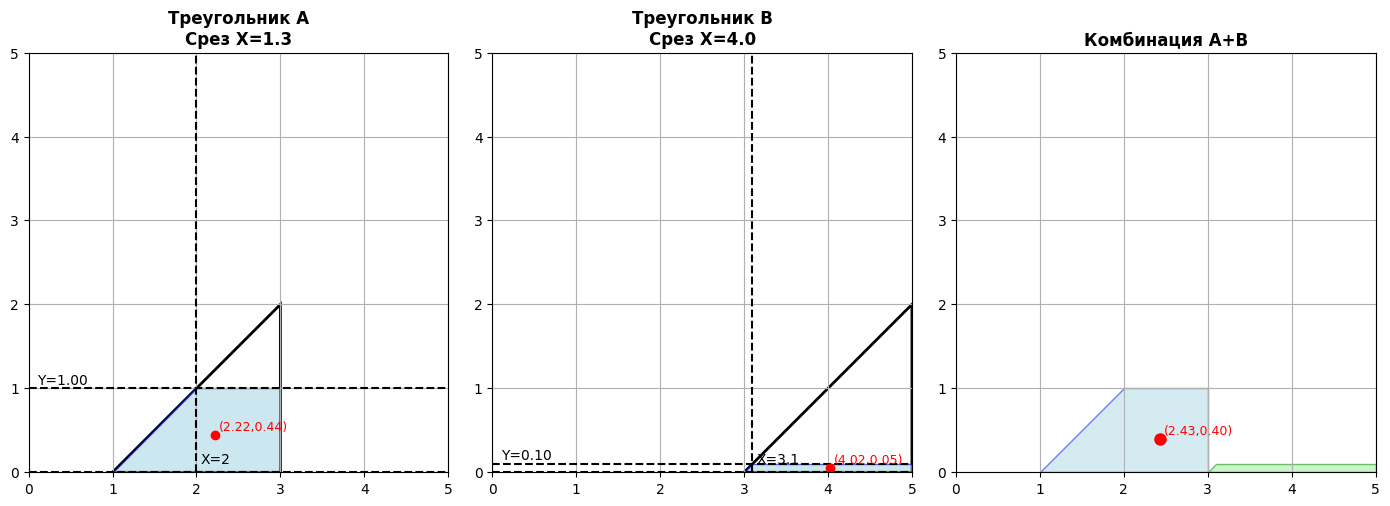

In [10]:
import matplotlib.pyplot as plt  # Импорт библиотеки для построения графиков
from matplotlib.patches import Polygon  # Импорт класса для рисования полигонов
from shapely.geometry import Polygon as ShapelyPolygon  # Импорт класса полигона Shapely для геометрических вычислений
from shapely.ops import unary_union  # Импорт функции объединения нескольких полигонов в один

# ==============================
# ТРЕУГОЛЬНИКИ - ОСНОВНЫЕ ФИГУРЫ
# ==============================
triangleA = [[1, 0], [3, 2], [3, 0]]  # Определение левого треугольника A: вершины (1,0), (3,2), (3,0)
triangleB = [[3, 0], [5, 2], [5, 0]]  # Определение правого треугольника B: вершины (3,0), (5,2), (5,0)

# ==============================
# ПАРАМЕТРЫ СРЕЗОВ ПО X
# ==============================
bottom_A = 0.0          # Нижняя граница среза для треугольника A (Y=0 - "пол")
x_cut_A = 2             # X-координата вертикального среза для A (Y вычисляется автоматически)

bottom_B = 0.0          # Нижняя граница среза для треугольника B (Y=0 - "пол")
x_cut_B = 3.1          # X-координата вертикального среза для B (Y вычисляется автоматически)

# ==============================
# НАХОДИМ ВЕРХНЕЕ Y ПО ЗАДАННОЙ X
# ==============================
def find_top_y_at_x(triangle, x_cut):  # Функция поиска максимальной Y на вертикали X=x_cut
    """Находит самое высокое Y на вертикали X = x_cut внутри треугольника."""
    ys = []  # Список для хранения найденных Y-координат
    for i in range(3):  # Перебираем 3 ребра треугольника
        p1, p2 = triangle[i], triangle[(i + 1) % 3]  # Текущая и следующая вершины (циклически)
        if (p1[0] - x_cut) * (p2[0] - x_cut) < 0:  # Проверка: ребро пересекает X=x_cut (разные знаки)
            t = (x_cut - p1[0]) / (p2[0] - p1[0])  # Параметр интерполяции t ∈ [0,1]
            y = p1[1] + t * (p2[1] - p1[1])  # Интерполируем Y в точке пересечения
            ys.append(y)  # Добавляем найденную Y
        if abs(p1[0] - x_cut) < 1e-9:  # Если вершина лежит точно на X=x_cut
            ys.append(p1[1])  # Добавляем Y вершины
    return max(ys) if ys else None  # Возвращаем максимальную Y или None

# ==============================
# РЕЗКА ПОЛИГОНА ПО ГОРИЗОНТАЛЬНОЙ ПОЛОСЕ
# ==============================
def slice_band(triangle, bottom, top):  # Функция резки полигона горизонтальной полосой Y∈[bottom,top]
    """Режет треугольник горизонтальной полосой Y∈[bottom, top]"""
    intersections_bottom = []  # Список точек пересечения с нижней границей Y=bottom
    intersections_top = []    # Список точек пересечения с верхней границей Y=top
    inside = []              # Список вершин внутри полосы

    for i in range(3):  # Перебираем 3 ребра
        p1, p2 = triangle[i], triangle[(i + 1) % 3]  # Текущая и следующая вершины
        if bottom <= p1[1] <= top:  # Если вершина внутри полосы
            inside.append(p1)  # Добавляем в список внутренних точек

        if (p1[1] - bottom) * (p2[1] - bottom) < 0:  # Ребро пересекает Y=bottom
            t = (bottom - p1[1]) / (p2[1] - p1[1])  # Параметр интерполяции
            x = p1[0] + t * (p2[0] - p1[0])  # X в точке пересечения
            intersections_bottom.append([x, bottom])  # Добавляем точку [X,bottom]

        if (p1[1] - top) * (p2[1] - top) < 0:  # Ребро пересекает Y=top
            t = (top - p1[1]) / (p2[1] - p1[1])  # Параметр интерполяции
            x = p1[0] + t * (p2[0] - p1[0])  # X в точке пересечения
            intersections_top.append([x, top])  # Добавляем точку [X,top]

    bottom_line = sorted(intersections_bottom + [p for p in inside if p[1] == bottom],  # Нижняя линия: слева→справа
                        key=lambda p: p[0])  # Сортировка по возрастанию X
    top_line = sorted(intersections_top + [p for p in inside if p[1] == top],  # Верхняя линия: справа→слева
                     key=lambda p: -p[0])  # Сортировка по убыванию X (важно для контура!)
    middle_points = [p for p in inside if bottom < p[1] < top]  # Вершины строго внутри полосы

    band = bottom_line + middle_points + top_line  # Объединяем: низ + середина + верх
    band_unique = []  # Удаление дубликатов точек
    for p in band:  # Перебираем точки контура
        if p not in band_unique:  # Если точка новая
            band_unique.append(p)  # Добавляем в уникальный список
    return band_unique  # Возвращаем контур среза

# ==============================
# РАСЧЁТ ЦЕНТРОИДА
# ==============================
def centroid(points):  # Вычисление центра масс одного полигона
    if len(points) < 3:  # Проверка: минимум 3 точки для полигона
        return None
    poly = ShapelyPolygon(points)  # Создание Shapely-полигона из списка точек
    if poly.is_valid:  # Проверка корректности полигона (не самопересекается)
        return [poly.centroid.x, poly.centroid.y]  # Координаты центроида [X,Y]
    return None  # Невалидный полигон

def combined_centroid(polys):  # Центроид объединения нескольких полигонов
    shapes = []  # Список валидных Shapely-полигонов
    for p in polys:  # Перебираем полигоны
        if len(p) >= 3:  # Минимум 3 точки
            poly = ShapelyPolygon(p)  # Создаём Shapely-полигон
            if poly.is_valid:  # Проверяем валидность
                shapes.append(poly)  # Добавляем в список
    if not shapes:  # Если нет валидных полигонов
        return None
    comb = unary_union(shapes)  # Объединяем все полигоны в один
    return [comb.centroid.x, comb.centroid.y]  # Центроид объединённого полигона

# ==============================
# РИСОВАНИЕ ОДНОГО ТРЕУГОЛЬНИКА СО СРЕЗОМ
# ==============================
def draw_triangle(ax, triangle, bottom, x_cut, name="A"):  # Функция рисования одного треугольника
    """Рисует треугольник, срез по X→Y и центроид"""
    top = find_top_y_at_x(triangle, x_cut)  # ★ Вычисляем верхнюю Y по заданной X
    if top is None:  # Если X не пересекает треугольник
        print(f"Ошибка: X={x_cut} не пересекает {name}")
        return []  # Возвращаем пустой срез

    band = slice_band(triangle, bottom, top)  # Вычисляем срезанный полигон

    # Исходный треугольник (чёрный контур)
    tri = Polygon(triangle, edgecolor='black', facecolor='none', linewidth=2)  # Создаём чёрный контур
    ax.add_patch(tri)  # Добавляем треугольник на график

    # Вертикальная линия среза X=x_cut
    ax.axvline(x_cut, color='k', linestyle='--')  # Чёрная пунктирная вертикаль
    ax.text(x_cut + 0.05, 0.1, f"X={x_cut}", color='black', fontsize=10)  # Подпись X

    # Горизонтальные линии среза
    ax.axhline(bottom, color='k', linestyle='--')  # Нижняя граница Y=bottom
    ax.axhline(top, color='k', linestyle='--')    # Верхняя граница Y=top

    # Подпись верхней Y
    ax.text(0.1, top + 0.05, f"Y={top:.2f}", color='black', fontsize=10)  # Подпись Y=top

    # Срезанный полигон и его центроид
    c = None  # Переменная для хранения центроида
    if len(band) >= 3:  # Если срез содержит минимум 3 точки
        poly = Polygon(band, edgecolor='blue', facecolor='lightblue', alpha=0.6)  # Синий заливка среза
        ax.add_patch(poly)  # Добавляем срез на график
        c = centroid(band)  # Вычисляем центроид среза
        if c:  # Если центроид существует
            ax.plot(c[0], c[1], 'ro', markersize=6)  # Красная точка центроида
            ax.text(c[0] + 0.05, c[1] + 0.05, f"({c[0]:.2f},{c[1]:.2f})",  # Подпись координат
                    color='red', fontsize=9)

    if c:  # Выводим координаты центроида в консоль
        print(f"{name} centroid (bottom={bottom}, top={top:.2f}, x_cut={x_cut}): "
              f"x={c[0]:.4f}, y={c[1]:.4f}")
    return band  # Возвращаем срез для дальнейшего использования

# ==============================
# КОМБИНИРОВАННЫЙ ГРАФИК A+B
# ==============================
def draw_combined(ax, tA, tB, bA, xA, bB, xB):  # Функция комбинированного графика
    """Рисует срезы A+B с одной общей точкой центроида"""
    # Вычисляем срезы без отрисовки индивидуальных центроидов
    bandA = slice_band(tA, bA, find_top_y_at_x(tA, xA))  # Срез треугольника A
    bandB = slice_band(tB, bB, find_top_y_at_x(tB, xB))  # Срез треугольника B

    # Срезы A (синий) + B (зелёный)
    if len(bandA) >= 3:  # Если срез A валиден
        ax.add_patch(Polygon(bandA, edgecolor='blue', facecolor='lightblue', alpha=0.5))  # Синяя заливка A
    if len(bandB) >= 3:  # Если срез B валиден
        ax.add_patch(Polygon(bandB, edgecolor='green', facecolor='lightgreen', alpha=0.5))  # Зелёная заливка B

    # ★ ТОЛЬКО одна общая точка центроида A+B ★
    c = combined_centroid([bandA, bandB])  # Центроид объединения A+B
    if c:  # Если центроид существует
        ax.plot(c[0], c[1], 'ro', markersize=8)  # Большая красная точка
        ax.text(c[0] + 0.05, c[1] + 0.05, f"({c[0]:.2f},{c[1]:.2f})",  # Подпись координат
                color='red', fontsize=9)
        print(f"A+B centroid (A.x={xA}, B.x={xB}): x={c[0]:.4f}, y={c[1]:.4f}")  # Вывод в консоль

# ==============================
# ГЛАВНАЯ ФУНКЦИЯ
# ==============================
def main():  # Главная функция - создаёт 3 графика рядом
    """Создаёт 1×3 графика с визуализацией стиля 1-го кода"""
    titles_A = ["Треугольник A\nСрез X=1.3"]  # Заголовок для графика A
    titles_B = ["Треугольник B\nСрез X=4.0"]  # Заголовок для графика B
    titles_AB = ["Комбинация A+B"]           # Заголовок для комбинированного графика

    fig, axes = plt.subplots(1, 3, figsize=(14, 14))  # Создаём 1×3 сетку квадратных графиков

    # График 1: Треугольник A с его центроидом
    draw_triangle(axes[0], triangleA, bottom_A, x_cut_A, name="A")  # Рисуем A
    axes[0].set_title(titles_A[0], fontsize=12, fontweight='bold')  # Заголовок A

    # График 2: Треугольник B с его центроидом
    draw_triangle(axes[1], triangleB, bottom_B, x_cut_B, name="B")  # Рисуем B
    axes[1].set_title(titles_B[0], fontsize=12, fontweight='bold')  # Заголовок B

    # График 3: Комбинация A+B с общей точкой
    draw_combined(axes[2], triangleA, triangleB, bottom_A, x_cut_A, bottom_B, x_cut_B)  # Рисуем A+B
    axes[2].set_title(titles_AB[0], fontsize=12, fontweight='bold')  # Заголовок A+B

    # Настройки осей для всех графиков
    for ax in [axes[0], axes[1], axes[2]]:  # Перебираем все 3 оси
        ax.set_xlim(0, 5)  # Границы X: от 0 до 5
        ax.set_ylim(0, 5)  # Границы Y: от 0 до 5
        ax.set_aspect('equal')  # Квадратная форма пикселей (не искажение)
        ax.grid(True)  # Включаем сетку

    plt.tight_layout()  # Автоматическая подгонка зазоров между графиками
    plt.show()  # ★ ПОКАЗЫВАЕМ ВСЕ 3 ГРАФИКА ★

if __name__ == "__main__":  # Точка входа программы
    main()  # Запускаем главную функцию